📊 Original training class distribution: Counter({2: 8331, 1: 1394, 0: 127})
✅ Balanced training class distribution: Counter({2: 8331, 1: 8331, 0: 8331})

🔍 Training: Logistic Regression

📊 Evaluation Report - Logistic Regression
Accuracy: 0.4566
              precision    recall  f1-score   support

           0      0.028     0.581     0.053        31
           1      0.180     0.358     0.239       349
           2      0.877     0.471     0.613      2084

    accuracy                          0.457      2464
   macro avg      0.361     0.470     0.302      2464
weighted avg      0.767     0.457     0.553      2464



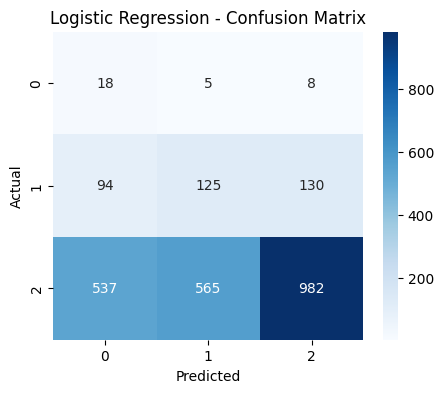


🔍 Training: Decision Tree

📊 Evaluation Report - Decision Tree
Accuracy: 0.7037
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        31
           1      0.146     0.181     0.161       349
           2      0.847     0.802     0.824      2084

    accuracy                          0.704      2464
   macro avg      0.331     0.327     0.328      2464
weighted avg      0.737     0.704     0.720      2464



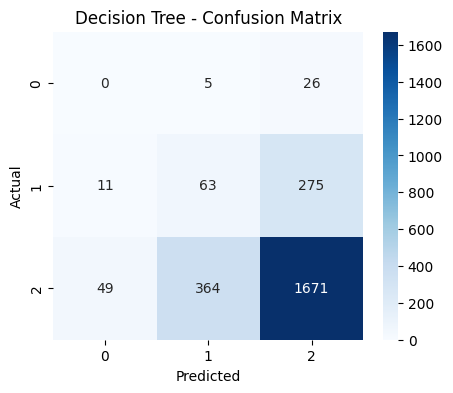


🔍 Training: Random Forest

📊 Evaluation Report - Random Forest
Accuracy: 0.8239
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        31
           1      0.198     0.052     0.082       349
           2      0.848     0.965     0.903      2084

    accuracy                          0.824      2464
   macro avg      0.349     0.339     0.328      2464
weighted avg      0.745     0.824     0.775      2464



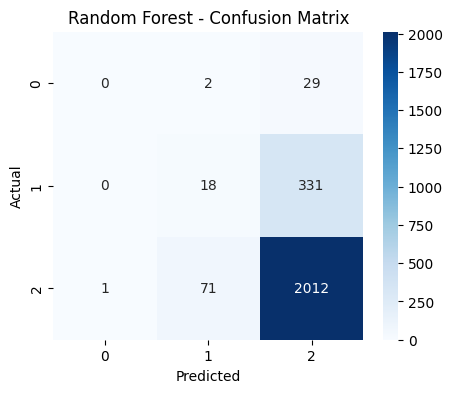

In [1]:
# Week 4 - Model Training (Balanced)

# --- Step 0: Load and prepare data ---
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Load dataset
df = pd.read_csv('../data/cleaned.csv')

# One-hot encode categorical variables
categorical_cols = [
    'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction',
    'Road_surface_type', 'Light_conditions', 'Weather_conditions',
    'Type_of_collision', 'Vehicle_movement', 'Pedestrian_movement',
    'Cause_of_accident', 'Vehicle_driver_relation'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Split features and target
X = df_encoded.drop(columns=['Accident_severity'])
y = df_encoded['Accident_severity']

# Ensure all features are numeric
assert X.select_dtypes(include=['object']).empty, "❌ Non-numeric columns present"

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Original training class distribution: {Counter(y_train)}")

# Apply class balancing (oversampling minority classes)
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print(f"✅ Balanced training class distribution: {Counter(y_train_bal)}")

# --- Step 1: Train models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    print(f"\n🔍 Training: {name}")
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_test)
    print(f"\n📊 Evaluation Report - {name}")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, digits=3))
    
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()